# Presentation · Mars contact sheets (vector)

**Primary interface** for the Mars pair contact sheets. This notebook calls
`channel_heads.viz.render_contact_sheet` — the same vector-network renderer the
batch scripts `scripts/rendering/render_mars_*_contact_sheet*.py` use (no
duplicated plotting logic).

It is **read-only**: it renders a small contact sheet **inline** (`output=None`)
and writes no PNGs. The full-resolution PNG sheets are produced by the batch
rendering scripts.

> Uses the combined-inference predictions under `data/Mars/model_outputs/`. If
> they are absent, the render cell reports that and stops gracefully.

In [1]:
import geopandas as gpd
import pandas as pd

from channel_heads.io.paths import PROJECT_ROOT
from channel_heads.viz import render_contact_sheet

PRED_PARQUET = PROJECT_ROOT / "data/Mars/model_outputs/mars_combined_model_predictions.parquet"
PAIRS_GPKG = PROJECT_ROOT / "data/Mars/topology/mars_vn_pairs.gpkg"
TOPOLOGY_GPKG = PROJECT_ROOT / "data/Mars/topology/mars_vn_topology_model_ready.gpkg"

HIGH_CONF_PROB_MIN = 0.80
N_PANELS = 10

have_data = PRED_PARQUET.exists() and PAIRS_GPKG.exists() and TOPOLOGY_GPKG.exists()
print("inputs present:", have_data)

inputs present: True


## Build the geometry lookups (read-only)

In [2]:
if have_data:
    df = pd.read_parquet(PRED_PARQUET)
    nodes_gdf = gpd.read_file(TOPOLOGY_GPKG, layer="mars_nodes")
    segs_gdf = gpd.read_file(TOPOLOGY_GPKG, layer="mars_segments")
    pair_paths = gpd.read_file(PAIRS_GPKG, layer="mars_pair_paths")

    nodes_by_nid = dict(tuple(nodes_gdf.groupby("network_id")))
    segs_by_nid = dict(tuple(segs_gdf.groupby("network_id")))

    outlets_by_nid = {}
    try:
        outlets_gdf = gpd.read_file(TOPOLOGY_GPKG, layer="mars_outlets")
        outlets_by_nid = {
            int(r["network_id"]): (float(r.geometry.x), float(r.geometry.y))
            for _, r in outlets_gdf.iterrows()
        }
    except Exception:
        pass  # outlet marker is optional

    paths_lookup = {
        (str(r["pair_id"]), str(r["branch"])): r.geometry
        for _, r in pair_paths.iterrows()
    }
    print(f"{len(df)} predictions, {len(nodes_by_nid)} networks")
else:
    print("inputs absent — skipping")

3785 predictions, 391 networks


## Top high-confidence touching pairs — rendered inline

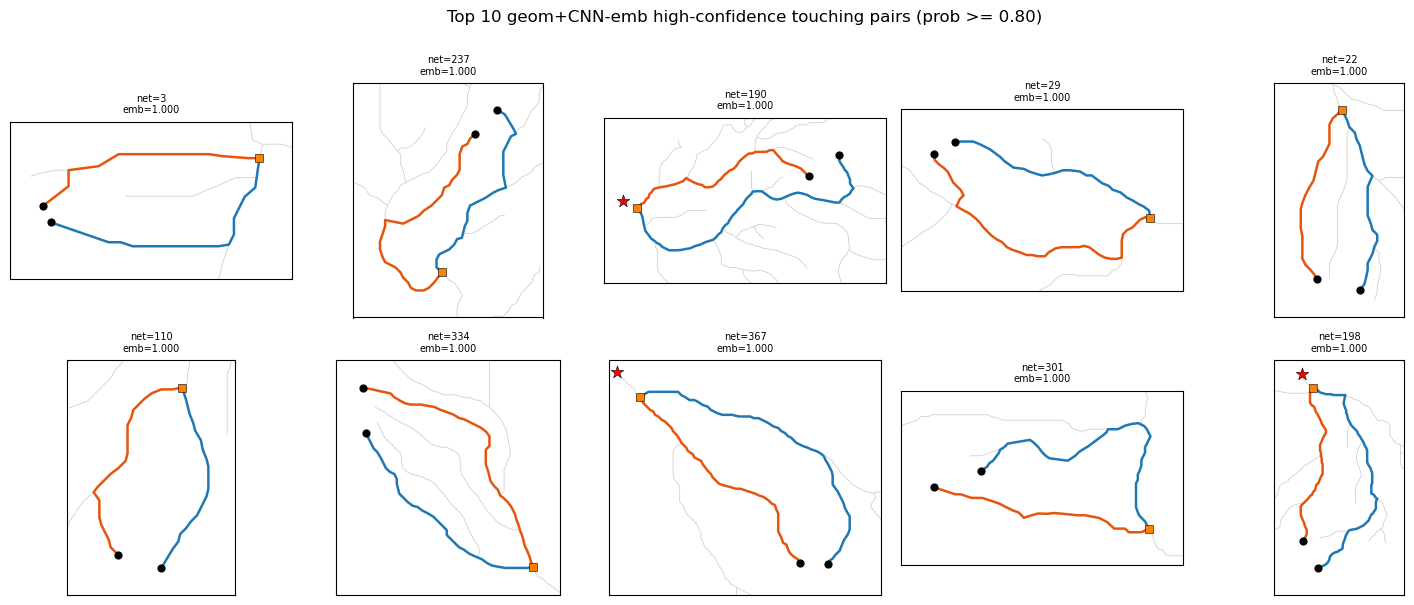

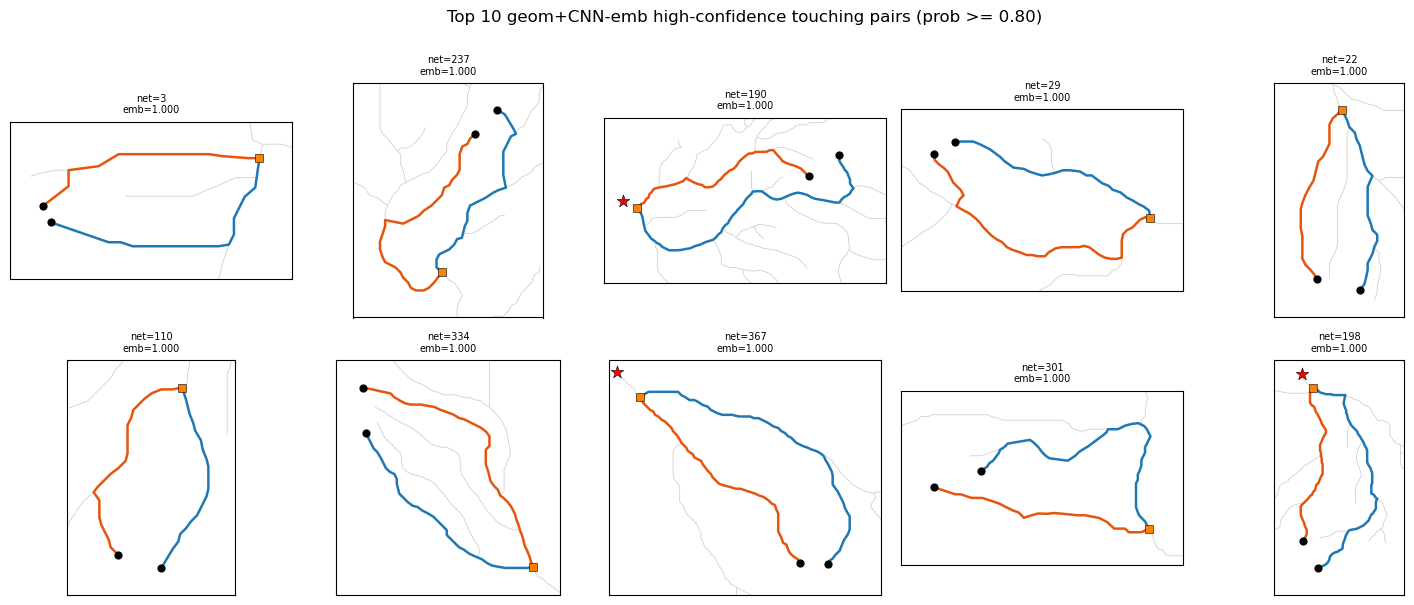

In [3]:
if have_data:
    rows = (
        df[df["prob_touching_emb"] >= HIGH_CONF_PROB_MIN]
        .sort_values("prob_touching_emb", ascending=False)
        .head(N_PANELS)
    )
    fig = render_contact_sheet(
        rows,
        nodes_by_nid,
        segs_by_nid,
        outlets_by_nid,
        paths_lookup,
        title=f"Top {len(rows)} geom+CNN-emb high-confidence touching pairs (prob >= {HIGH_CONF_PROB_MIN:.2f})",
        subtitle_fn=lambda r: f"net={int(r['network_id'])}\nemb={r['prob_touching_emb']:.3f}",
        output=None,  # inline, no file written
    )
else:
    fig = None
    print("Run the batch renderer:")
    print("  python scripts/rendering/render_mars_high_conf_emb_contact_sheet.py")
fig

---
Full-resolution PNG contact sheets (written to `data/Mars/model_outputs/`):

```bash
python scripts/rendering/render_mars_high_conf_emb_contact_sheet.py
python scripts/rendering/render_mars_combined_contact_sheets_vector.py
```